# Predykcja płatności klientów – sklearn Pipeline

**Problem biznesowy:** Przewidujemy, które zamówienia zostaną zapłacone i jaka będzie wartość płatności.
Dzięki temu dział sprzedaży może priorytetyzować klientów wysokiego ryzyka.

**Podejście:**
1. EDA – zrozumienie danych
2. Feature engineering – tworzenie cech z sensem biznesowym
3. sklearn Pipeline – preprocessing + model w jednym obiekcie
4. Cross-validation – rzetelna ewaluacja (bez data leakage)
5. Feature importance – interpretacja modelu

## 1. Importy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Wczytanie i wstępna inspekcja danych

Zawsze zaczynamy od `.info()`, `.describe()` i sprawdzenia braków.
To podstawa dobrego EDA – bez tego nie wiemy co przetwarzać.

In [2]:
df = pd.read_csv('zamowienia_testowe.csv')

print(f"Wymiary datasetu: {df.shape}")
print(f"\nTypy kolumn:")
print(df.dtypes)
print(f"\nPierwsze 5 wierszy:")
df.head()

Wymiary datasetu: (150, 9)

Typy kolumn:
ID                       int64
Data zamowienia         object
Nazwa klienta           object
Sprzedawca              object
Branża                  object
Liczba produktow         int64
Wartosc jednostkowa    float64
Zapłacono              float64
Komentarz               object
dtype: object

Pierwsze 5 wierszy:


,ID,Data zamowienia,Nazwa klienta,Sprzedawca,Branża,Liczba produktow,Wartosc jednostkowa,Zapłacono,Komentarz
0,1001,2023-01-01,MedSupply,Anna Wiśniewska,Medycyna,39,325.48,17793.10,Pilne
1,1002,2023-01-04,LogiTrans,Anna Wiśniewska,Energia,29,170.89,5861.00,NaN
2,1003,2023-01-08,PrintMaster,Piotr Kowalczyk,IT / Technologia,15,264.11,5396.26,Klient VIP
3,1004,2023-01-11,Nowak Trading,Tomasz Nowak,Rolnictwo,43,455.63,17374.71,Pilne
4,1005,2023-01-15,LogiTrans,Anna Wiśniewska,Budownictwo,8,139.66,1539.99,NaN


In [3]:
# Braki danych – procent nullów w każdej kolumnie
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

if missing.empty:
    print("Brak wartości NULL w datasecie.")
else:
    print("Procent braków danych:")
    print(missing.round(2))

Procent braków danych:
Komentarz    41.33
dtype: float64


Statystyki zmiennej target 'Zapłacono':
count      150.000000
mean      7019.962600
std       6152.986265
min         50.000000
25%       2127.590000
50%       4847.585000
75%      10829.325000
max      26204.310000
Name: Zapłacono, dtype: float64


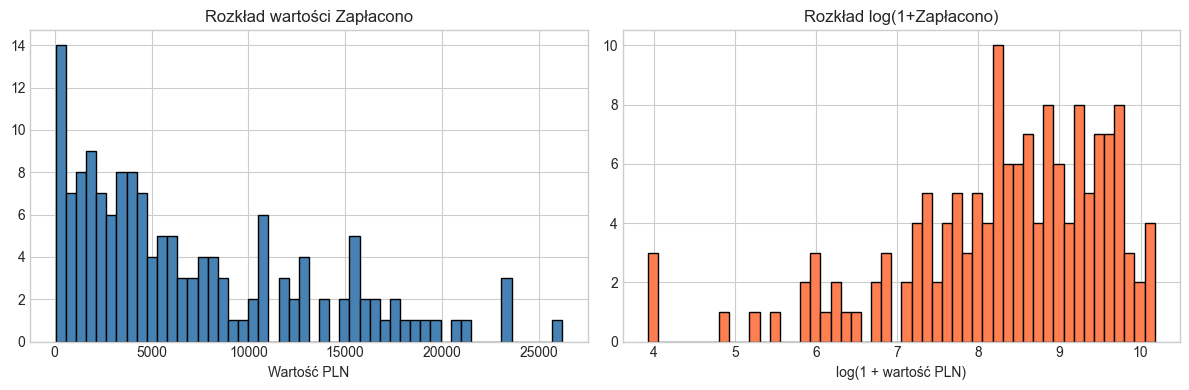

In [4]:
# Statystyki opisowe zmiennej target
df['Zapłacono'] = df['Zapłacono'].astype(str).str.replace(',', '.').astype(float)

print("Statystyki zmiennej target 'Zapłacono':")
print(df['Zapłacono'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Zapłacono'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Rozkład wartości Zapłacono')
axes[0].set_xlabel('Wartość PLN')

# Log-transform ujawnia ukrytą strukturę w danych skośnych
log_vals = np.log1p(df['Zapłacono'].clip(lower=0))
axes[1].hist(log_vals, bins=50, edgecolor='black', color='coral')
axes[1].set_title('Rozkład log(1+Zapłacono)')
axes[1].set_xlabel('log(1 + wartość PLN)')

plt.tight_layout()
plt.show()

## 3. Feature Engineering

Feature engineering to miejsce, gdzie wkładamy **wiedzę domenową** w model.
AutoML tego nie robi – to właśnie odróżnia dobrego DS od sklecenia `compare_models()`.

In [5]:
df_model = df.copy()

# Usuń kolumny-identyfikatory (nie wnoszą informacji predykcyjnej)
cols_to_drop = ['ID', 'Komentarz']
df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns], inplace=True)

# --- Cechy z dat (jeśli istnieją kolumny z datą) ---
date_cols = [c for c in df_model.columns if 'data' in c.lower() or 'date' in c.lower()]
for col in date_cols:
    try:
        df_model[col] = pd.to_datetime(df_model[col])
        df_model[f'{col}_miesiac'] = df_model[col].dt.month
        df_model[f'{col}_dzien_tygodnia'] = df_model[col].dt.dayofweek
        df_model[f'{col}_kwartal'] = df_model[col].dt.quarter
        df_model.drop(columns=[col], inplace=True)
        print(f"Stworzono cechy z kolumny dat: {col}")
    except Exception:
        pass

print(f"\nKolumny po feature engineering: {list(df_model.columns)}")
print(f"Wymiary: {df_model.shape}")

Stworzono cechy z kolumny dat: Data zamowienia

Kolumny po feature engineering: ['Nazwa klienta', 'Sprzedawca', 'Branża', 'Liczba produktow', 'Wartosc jednostkowa', 'Zapłacono', 'Data zamowienia_miesiac', 'Data zamowienia_dzien_tygodnia', 'Data zamowienia_kwartal']
Wymiary: (150, 9)


## 4. Podział na cechy i target

Separujemy X (cechy wejściowe) od y (to co chcemy przewidzieć).
Następnie dzielimy dane: **80% trening, 20% test** – test set zostaje zablokowany do końca.

In [6]:
TARGET = 'Zapłacono'

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Automatyczny podział kolumn na numeryczne i kategoryczne
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Kolumny numeryczne ({len(num_cols)}): {num_cols}")
print(f"Kolumny kategoryczne ({len(cat_cols)}): {cat_cols}")

Train: (120, 8), Test: (30, 8)
Kolumny numeryczne (5): ['Liczba produktow', 'Wartosc jednostkowa', 'Data zamowienia_miesiac', 'Data zamowienia_dzien_tygodnia', 'Data zamowienia_kwartal']
Kolumny kategoryczne (3): ['Nazwa klienta', 'Sprzedawca', 'Branża']


## 5. sklearn Pipeline – preprocessing + model

**Pipeline** to kluczowy pattern w produkcyjnym ML.

Dlaczego pipeline zamiast ręcznych transformacji?
- **Brak data leakage** – scaler uczy się tylko na danych treningowych
- **Jeden obiekt do deploymentu** – `pipeline.predict(X_new)` robi wszystko
- **Łatwy cross-validation** – CV wie jak przetworzyć każdy fold oddzielnie

`ColumnTransformer` pozwala zastosować różne transformacje do różnych kolumn jednocześnie.

In [7]:
# Preprocessing dla kolumn numerycznych: uzupełnij braki medianą, standaryzuj
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing dla kolumn kategorycznych: uzupełnij braków jako 'missing', one-hot encode
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='drop')

# Porównujemy 3 modele – od prostego do złożonego
models = {
    'Ridge (baseline)': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
}

print("Ewaluacja modeli (5-fold CV na zbiorze treningowym):")
print(f"{'Model':<25} {'MAE (mean)':>12} {'MAE (std)':>10} {'R2 (mean)':>10}")
print("-" * 60)

results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    mae_scores = -cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2')
    
    results[name] = {'mae_mean': mae_scores.mean(), 'mae_std': mae_scores.std(), 'r2_mean': r2_scores.mean()}
    print(f"{name:<25} {mae_scores.mean():>12.2f} {mae_scores.std():>10.2f} {r2_scores.mean():>10.3f}")

Ewaluacja modeli (5-fold CV na zbiorze treningowym):
Model                       MAE (mean)  MAE (std)  R2 (mean)
------------------------------------------------------------
Ridge (baseline)               2159.96     302.67      0.761
Random Forest                  1472.38     177.33      0.880
Gradient Boosting              1157.87     129.24      0.918


## 6. Finalny model – ewaluacja na zbiorze testowym

Wybieramy najlepszy model (najniższy MAE z CV) i trenujemy go na **całym** zbiorze treningowym.
Dopiero teraz patrzymy na zbiór testowy – raz, na koniec. To jest właściwy sposób.

In [8]:
best_name = min(results, key=lambda k: results[k]['mae_mean'])
print(f"Najlepszy model wg MAE z cross-validation: {best_name}")

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models[best_name])
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n--- Wyniki na zbiorze testowym (hold-out) ---")
print(f"MAE  (Mean Absolute Error): {mae:.2f} PLN")
print(f"RMSE (Root Mean Sq Error):  {rmse:.2f} PLN")
print(f"R²   (Wariancja wyjaśniona): {r2:.3f}")
print(f"\nInterpretacja: Model myli się średnio o {mae:.2f} PLN na zamówieniu.")

Najlepszy model wg MAE z cross-validation: Gradient Boosting

--- Wyniki na zbiorze testowym (hold-out) ---
MAE  (Mean Absolute Error): 1301.65 PLN
RMSE (Root Mean Sq Error):  1963.11 PLN
R²   (Wariancja wyjaśniona): 0.910

Interpretacja: Model myli się średnio o 1301.65 PLN na zamówieniu.


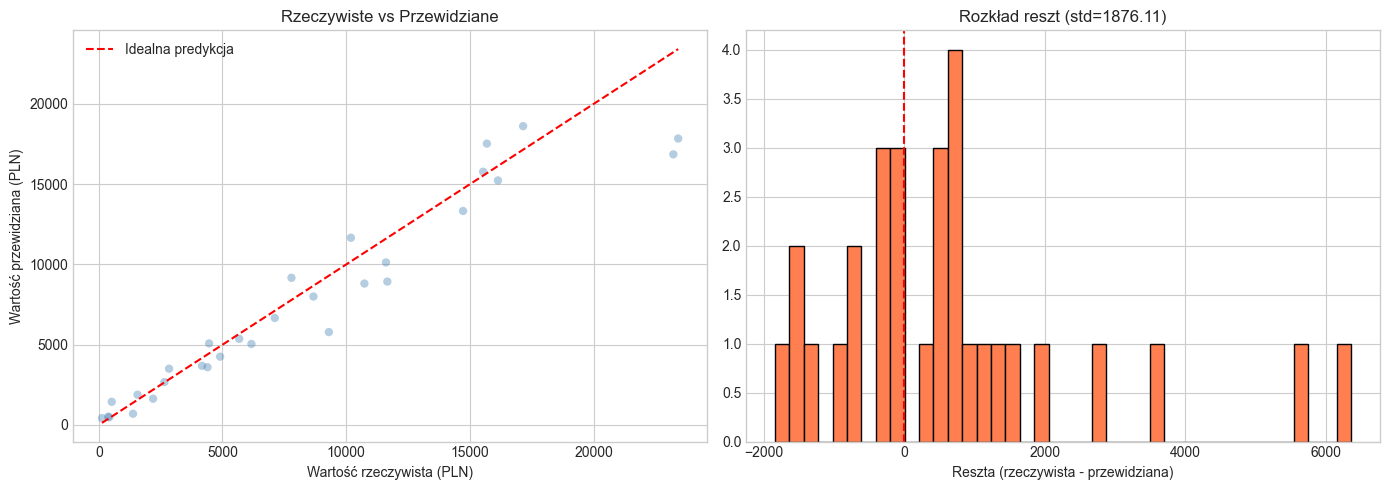

In [9]:
# Wykres: Prawdziwe vs Przewidziane wartości + rozkład reszt
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.4, edgecolors='none', color='steelblue')
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Idealna predykcja')
axes[0].set_xlabel('Wartość rzeczywista (PLN)')
axes[0].set_ylabel('Wartość przewidziana (PLN)')
axes[0].set_title('Rzeczywiste vs Przewidziane')
axes[0].legend()

# Histogram reszt
axes[1].hist(residuals, bins=40, edgecolor='black', color='coral')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Reszta (rzeczywista - przewidziana)')
axes[1].set_title(f'Rozkład reszt (std={residuals.std():.2f})')

plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Feature Importance

Które cechy model uznaje za najważniejsze?
To kluczowe dla DS – rozumiesz model i możesz go uzasadnić biznesowo.

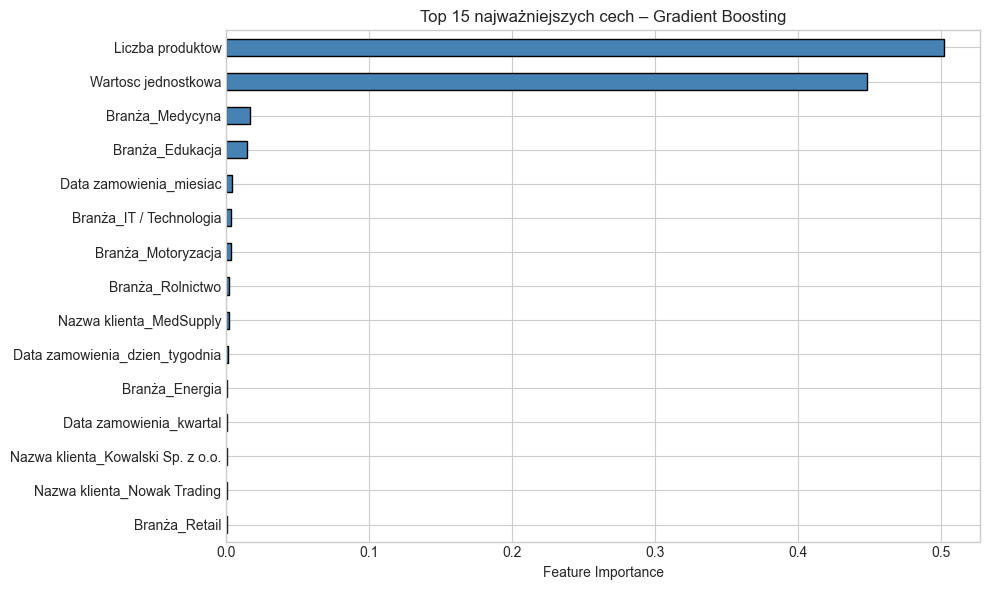

In [10]:
final_model = best_pipeline.named_steps['model']

if hasattr(final_model, 'feature_importances_'):
    # Pobierz nazwy cech po transformacji
    ohe = best_pipeline.named_steps['preprocessor'].named_transformers_.get('cat')
    if ohe and cat_cols:
        cat_feature_names = best_pipeline.named_steps['preprocessor'] \
            .named_transformers_['cat'] \
            .named_steps['encoder'] \
            .get_feature_names_out(cat_cols).tolist()
    else:
        cat_feature_names = []
    
    feature_names = num_cols + cat_feature_names
    importances = pd.Series(final_model.feature_importances_, index=feature_names)
    top_features = importances.sort_values(ascending=False).head(15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top_features.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Top 15 najważniejszych cech – {best_name}')
    ax.set_xlabel('Feature Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print(f"Model {best_name} nie wspiera feature_importances_. Użyj modelu drzewiastego.")

## 8. Predykcje i zapis wyników

Generujemy predykcje na całym datasecie i zapisujemy z metadanymi:
- `prediction_label` – 1 jeśli przewidywana wartość > mediany ("zapłaci"), 0 jeśli nie
- `prediction_score` – dokładna przewidziana wartość PLN

In [11]:
X_all = df_model.drop(columns=[TARGET])
y_all = df_model[TARGET]

predictions_all = best_pipeline.predict(X_all)

# Retrain na całości danych (po finalnej ewaluacji)
best_pipeline.fit(X_all, y_all)

output_df = df.copy()
output_df['prediction_score'] = predictions_all.round(2)

median_threshold = np.median(predictions_all)
output_df['prediction_label'] = (predictions_all > median_threshold).astype(int)

output_df.to_csv('predykcje.csv', index=False)

print(f"Zapisano predykcje do 'predykcje.csv'")
print(f"Threshold (mediana): {median_threshold:.2f} PLN")
print(f"Przewidziane jako zapłacone (1): {output_df['prediction_label'].sum()}")
print(f"Przewidziane jako niezapłacone (0): {(output_df['prediction_label']==0).sum()}")
output_df.head()

Zapisano predykcje do 'predykcje.csv'
Threshold (mediana): 4867.40 PLN
Przewidziane jako zapłacone (1): 75
Przewidziane jako niezapłacone (0): 75


,ID,Data zamowienia,Nazwa klienta,Sprzedawca,Branża,Liczba produktow,Wartosc jednostkowa,Zapłacono,Komentarz,prediction_score,prediction_label
0,1001,2023-01-01,MedSupply,Anna Wiśniewska,Medycyna,39,325.48,17793.10,Pilne,17650.45,1
1,1002,2023-01-04,LogiTrans,Anna Wiśniewska,Energia,29,170.89,5861.00,NaN,5732.12,1
2,1003,2023-01-08,PrintMaster,Piotr Kowalczyk,IT / Technologia,15,264.11,5396.26,Klient VIP,5227.25,1
3,1004,2023-01-11,Nowak Trading,Tomasz Nowak,Rolnictwo,43,455.63,17374.71,Pilne,17263.18,1
4,1005,2023-01-15,LogiTrans,Anna Wiśniewska,Budownictwo,8,139.66,1539.99,NaN,1634.73,0


## 9. Zapis modelu

Zapisujemy cały pipeline (preprocessing + model) jako jeden plik.
Dzięki temu `app.py` może załadować model i robić predykcje bez żadnych dodatkowych kroków.

In [12]:
import joblib

joblib.dump(best_pipeline, 'model_pipeline.pkl')
print("Pipeline zapisany jako 'model_pipeline.pkl'")
print(f"Model: {best_name}")
print(f"Metryki testowe: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

Pipeline zapisany jako 'model_pipeline.pkl'
Model: Gradient Boosting
Metryki testowe: MAE=1301.65, RMSE=1963.11, R2=0.910
